# Movie Similarity Analysis: Finding Hidden Gems

**Author:** Dany Drammeh  
**Date:** March 13th 2026  
**Data Source:** TMDB API

## Step 1: Import Libraries

In [1]:
import requests
import pandas as pd
import numpy as np
import time
import json
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import euclidean

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)

✓ Libraries imported


## Step 2: API Setup and Data Collection

In [5]:
# TMDB API Key - Get yours at https://www.themoviedb.org/settings/api
API_KEY = "fcc88b7f350398a40f949f172bbfe741"
BASE_URL = "https://api.themoviedb.org/3"

In [6]:
def get_movies_by_page(page, min_votes=50):
    """
    Fetch movies from TMDB API with retry logic.
    """
    url = f"{BASE_URL}/movie/popular"
    params = {
        'api_key': API_KEY,
        'page': page,
        'language': 'en-US'
    }

    for attempt in range(5):
        try:
            response = requests.get(url, params=params, timeout=10)
            response.raise_for_status()
            return response.json()['results']
        except requests.exceptions.HTTPError as e:
            if e.response.status_code == 429:
                wait_time = 2 ** attempt
                print(f"Rate limit hit. Waiting {wait_time}s...")
                time.sleep(wait_time)
            else:
                raise
        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(2)

    return []

def get_movie_details(movie_id):
    """
    Get detailed info including keywords for a specific movie.
    """
    url = f"{BASE_URL}/movie/{movie_id}"
    params = {
        'api_key': API_KEY,
        'append_to_response': 'keywords'
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        return response.json()
    except:
        return None

In [7]:
# Collect 3000 movies (150 pages * 20 movies per page)
print("Collecting movies from TMDB API...")
all_movies = []

for page in range(1, 151):
    movies = get_movies_by_page(page)
    all_movies.extend(movies)

    if page % 25 == 0:
        print(f"Collected {len(all_movies)} movies (page {page}/150)")

    time.sleep(0.25)

print(f"\n✓ Total movies collected: {len(all_movies)}")

Collected 500 movies (page 25/150)
Collected 1000 movies (page 50/150)
Collected 1500 movies (page 75/150)
Collected 2000 movies (page 100/150)
Collected 2500 movies (page 125/150)
Collected 3000 movies (page 150/150)

✓ Total movies collected: 3000


## Step 3: Create Initial DataFrame

In [8]:
df = pd.DataFrame(all_movies)

print(f"Initial shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Initial shape: (3000, 14)

Columns: ['adult', 'backdrop_path', 'genre_ids', 'id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'release_date', 'title', 'video', 'vote_average', 'vote_count']

First few rows:


,adult,backdrop_path,genre_ids,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count
0,False,/1x9e0qWonw634NhIsRdvnneeqvN.jpg,"[10749, 18]",1523145,ru,Твое сердце будет разбито,High school student Polina is saved from bully...,543.5230,/iGpMm603GUKH2SiXB2S5m4sZ17t.jpg,2026-03-26,Your Heart Will Be Broken,False,6.400,7
1,False,/1fkuBPid72KGS6WmtkEXMftZtkE.jpg,"[80, 18]",875828,en,Peaky Blinders: The Immortal Man,After his estranged son gets embroiled in a Na...,337.6486,/gRMalasZEzsZi4w2VFuYusfSfqf.jpg,2026-03-05,Peaky Blinders: The Immortal Man,False,7.390,453
2,False,/sdZSjtGUTSN8B3al5o0f2WoQfQQ.jpg,"[878, 12, 14]",83533,en,Avatar: Fire and Ash,In the wake of the devastating war against the...,305.6897,/bRBeSHfGHwkEpImlhxPmOcUsaeg.jpg,2025-12-17,Avatar: Fire and Ash,False,7.259,1940
3,False,/8Tfys3mDZVp4tNoH2ktm06a0Tau.jpg,"[878, 12]",687163,en,Project Hail Mary,Science teacher Ryland Grace wakes up on a spa...,303.9914,/yihdXomYb5kTeSivtFndMy5iDmf.jpg,2026-03-15,Project Hail Mary,False,8.189,543
4,False,/6GuqUJ33BnWDAoVPZP55gDr5G55.jpg,"[28, 53, 27]",1084187,en,Pretty Lethal,A troupe of ballerinas find themselves fightin...,303.7242,/znTPnXCK3lEQJgqXCvP7e5FUz6f.jpg,2026-03-13,Pretty Lethal,False,6.903,62


## Step 4: Data Cleaning

In [9]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Fill missing overviews with empty string
df['overview'] = df['overview'].fillna('')

# Remove movies with no title or no genres
df = df[df['title'].notna()]
df = df[df['genre_ids'].apply(len) > 0]

# Filter minimum vote count (reduce noise from obscure films)
df = df[df['vote_count'] >= 50]

# Remove duplicates based on title
df = df.drop_duplicates(subset=['title'], keep='first')

# Reset index
df = df.reset_index(drop=True)

print(f"\n✓ After cleaning: {df.shape}")
print(f"Removed {len(all_movies) - len(df)} movies")

Missing values:
adult                  0
backdrop_path        103
genre_ids              0
id                     0
original_language      0
original_title         0
overview               0
popularity             0
poster_path           26
release_date           0
title                  0
video                  0
vote_average           0
vote_count             0
dtype: int64

✓ After cleaning: (2266, 14)
Removed 734 movies


## Step 5: Genre Mapping

In [10]:
# TMDB genre ID to name mapping
genre_map = {
    28: 'Action', 12: 'Adventure', 16: 'Animation', 35: 'Comedy', 80: 'Crime',
    99: 'Documentary', 18: 'Drama', 10751: 'Family', 14: 'Fantasy', 36: 'History',
    27: 'Horror', 10402: 'Music', 9648: 'Mystery', 10749: 'Romance', 878: 'Science Fiction',
    10770: 'TV Movie', 53: 'Thriller', 10752: 'War', 37: 'Western'
}

# Convert genre IDs to names
df['genres'] = df['genre_ids'].apply(lambda x: [genre_map.get(id, 'Unknown') for id in x])
df['genre_string'] = df['genres'].apply(lambda x: ' '.join(x))

print("Genre distribution:")
all_genres = [genre for genres in df['genres'] for genre in genres]
genre_counts = Counter(all_genres)
for genre, count in genre_counts.most_common(10):
    print(f"  {genre:20s}: {count}")

Genre distribution:
  Action              : 821
  Drama               : 817
  Thriller            : 648
  Comedy              : 636
  Adventure           : 604
  Science Fiction     : 408
  Crime               : 358
  Fantasy             : 355
  Romance             : 309
  Horror              : 303


## Step 6: Feature Engineering

In [11]:
# Extract year from release_date
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df['year'] = df['year'].fillna(df['year'].median())

# Create "hidden gem" score: high rating, low votes
df['hidden_gem_score'] = df['vote_average'] / np.log1p(df['vote_count'])

# Normalize vote_average to 0-1 scale
df['rating_normalized'] = df['vote_average'] / 10.0

# Combined text for TF-IDF (overview + genres)
df['combined_text'] = df['overview'] + ' ' + df['genre_string']

print("✓ Features engineered")
print(f"\nDataset overview:")
print(df[['title', 'year', 'vote_average', 'vote_count', 'hidden_gem_score']].head(10))

✓ Features engineered

Dataset overview:
                              title  year  vote_average  vote_count  \
0  Peaky Blinders: The Immortal Man  2026         7.390         453   
1              Avatar: Fire and Ash  2025         7.259        1940   
2                 Project Hail Mary  2026         8.189         543   
3                     Pretty Lethal  2026         6.903          62   
4                           Shelter  2026         6.698         399   
5                          Scream 7  2026         5.813         466   
6                       War Machine  2026         7.273        1174   
7                         Crime 101  2026         7.000         215   
8                         Send Help  2026         7.100         562   
9            Greenland 2: Migration  2026         6.423         705   

   hidden_gem_score  
0          1.207892  
1          0.958795  
2          1.300058  
3          1.666130  
4          1.117924  
5          0.945768  
6          1.028855  
7

## Step 7: Text Similarity (TF-IDF + Cosine)

In [12]:
# Create TF-IDF matrix from combined text
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2
)

tfidf_matrix = tfidf.fit_transform(df['combined_text'])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")

# Compute cosine similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f"Cosine similarity matrix shape: {cosine_sim.shape}")

TF-IDF matrix shape: (2266, 5000)
Vocabulary size: 5000
Cosine similarity matrix shape: (2266, 2266)


## Step 8: Genre Similarity (Jaccard)

In [13]:
def jaccard_similarity(set1, set2):
    """
    Calculate Jaccard similarity between two sets.
    """
    intersection = len(set(set1).intersection(set(set2)))
    union = len(set(set1).union(set(set2)))
    return intersection / union if union > 0 else 0

# Compute Jaccard similarity matrix for genres
n = len(df)
jaccard_sim = np.zeros((n, n))

for i in range(n):
    for j in range(i, n):
        sim = jaccard_similarity(df.iloc[i]['genres'], df.iloc[j]['genres'])
        jaccard_sim[i, j] = sim
        jaccard_sim[j, i] = sim

    if (i + 1) % 500 == 0:
        print(f"Computed Jaccard similarity for {i + 1}/{n} movies")

print(f"\n✓ Jaccard similarity matrix shape: {jaccard_sim.shape}")

Computed Jaccard similarity for 500/2266 movies
Computed Jaccard similarity for 1000/2266 movies
Computed Jaccard similarity for 1500/2266 movies
Computed Jaccard similarity for 2000/2266 movies

✓ Jaccard similarity matrix shape: (2266, 2266)


## Step 9: Numerical Feature Similarity (Normalized Euclidean)

In [14]:
# Select numerical features
numerical_features = ['vote_average', 'year']
X = df[numerical_features].values

# Normalize to 0-1 range
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# Compute pairwise Euclidean distances
n = len(df)
euclidean_dist = np.zeros((n, n))

for i in range(n):
    for j in range(i, n):
        dist = euclidean(X_normalized[i], X_normalized[j])
        euclidean_dist[i, j] = dist
        euclidean_dist[j, i] = dist

# Convert distance to similarity (1 - normalized_distance)
max_dist = euclidean_dist.max()
euclidean_sim = 1 - (euclidean_dist / max_dist)

print(f"✓ Euclidean similarity matrix shape: {euclidean_sim.shape}")

✓ Euclidean similarity matrix shape: (2266, 2266)


## Step 10: Combined Hybrid Similarity Score

In [15]:
# Weighted combination of all similarity metrics
weights = {
    'cosine': 0.5,      # Text similarity (plot + genres)
    'jaccard': 0.3,     # Genre overlap
    'euclidean': 0.2    # Numerical features (rating, year)
}

combined_similarity = (
    weights['cosine'] * cosine_sim +
    weights['jaccard'] * jaccard_sim +
    weights['euclidean'] * euclidean_sim
)

print(f"Combined similarity matrix shape: {combined_similarity.shape}")
print(f"\nSimilarity score range: [{combined_similarity.min():.3f}, {combined_similarity.max():.3f}]")

Combined similarity matrix shape: (2266, 2266)

Similarity score range: [0.000, 1.000]


## Step 11: Define Query Movies

In [16]:
# Three diverse query movies
query_movies = [
    'Inception',
    'The Shawshank Redemption',
    'Interstellar'
]

# Find query movies in dataset
query_indices = {}

for movie_title in query_movies:
    matches = df[df['title'].str.contains(movie_title, case=False, na=False)]
    if len(matches) > 0:
        idx = matches.index[0]
        query_indices[movie_title] = idx
        print(f"Found: {df.iloc[idx]['title']} ({df.iloc[idx]['year']:.0f}) - Index: {idx}")
    else:
        print(f"Not found: {movie_title}")

print(f"\n✓ Query movies located: {len(query_indices)}")

Found: Inception (2010) - Index: 94
Found: The Shawshank Redemption (1994) - Index: 60
Found: Interstellar (2014) - Index: 54

✓ Query movies located: 3


## Step 12: Find Top 10 Similar Movies for Each Query

In [17]:
def get_top_similar_movies(query_idx, similarity_matrix, df, n=10):
    """
    Get top N most similar movies to the query movie.
    """
    # Get similarity scores for this movie
    sim_scores = list(enumerate(similarity_matrix[query_idx]))

    # Sort by similarity (descending)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get top N+1 (excluding the movie itself)
    sim_scores = sim_scores[1:n+1]

    # Get movie indices
    movie_indices = [i[0] for i in sim_scores]
    similarity_scores = [i[1] for i in sim_scores]

    # Create results dataframe
    results = df.iloc[movie_indices][['title', 'year', 'vote_average', 'vote_count', 'genres', 'hidden_gem_score']].copy()
    results['similarity_score'] = similarity_scores
    results['rank'] = range(1, n+1)

    return results[['rank', 'title', 'year', 'similarity_score', 'vote_average', 'vote_count', 'genres', 'hidden_gem_score']]

In [18]:
# Store results for all queries
all_results = {}

for movie_title, idx in query_indices.items():
    print(f"\n{'='*80}")
    print(f"QUERY: {df.iloc[idx]['title']} ({df.iloc[idx]['year']:.0f})")
    print(f"Genres: {', '.join(df.iloc[idx]['genres'])}")
    print(f"Rating: {df.iloc[idx]['vote_average']}/10 ({df.iloc[idx]['vote_count']:.0f} votes)")
    print(f"{'='*80}")

    results = get_top_similar_movies(idx, combined_similarity, df, n=10)
    all_results[movie_title] = results

    print("\nTop 10 Similar Movies:")
    print(results.to_string(index=False))
    print("\n")


QUERY: Inception (2010)
Genres: Action, Science Fiction, Adventure
Rating: 8.371/10 (38891 votes)

Top 10 Similar Movies:
 rank                                        title  year  similarity_score  vote_average  vote_count                               genres  hidden_gem_score
    1                                     Iron Man  2008          0.541234         7.656       27878 [Action, Science Fiction, Adventure]          0.747976
    2                            The Fifth Element  1997          0.538846         7.565       11546 [Science Fiction, Action, Adventure]          0.808729
    3               Guardians of the Galaxy Vol. 2  2017          0.538528         7.609       22742 [Science Fiction, Adventure, Action]          0.758472
    4                           Predator: Badlands  2025          0.534565         7.694        2489 [Action, Science Fiction, Adventure]          0.983883
    5                                Thunderbolts*  2025          0.533276         7.290        3

## Step 13: Identify Hidden Gems in Recommendations

In [19]:
# Define "hidden gem" threshold (high rating, relatively low votes)
VOTE_THRESHOLD = 5000  # Movies with fewer than 5000 votes
RATING_THRESHOLD = 7.5  # Rating >= 7.5

for movie_title, results in all_results.items():
    print(f"\n{'='*80}")
    print(f"HIDDEN GEMS for '{movie_title}':")
    print(f"{'='*80}")

    hidden_gems = results[
        (results['vote_count'] < VOTE_THRESHOLD) &
        (results['vote_average'] >= RATING_THRESHOLD)
    ]

    if len(hidden_gems) > 0:
        print(hidden_gems[['rank', 'title', 'year', 'vote_average', 'vote_count', 'similarity_score']].to_string(index=False))
    else:
        print("No hidden gems found in top 10 (adjusting thresholds might help)")
    print("\n")


HIDDEN GEMS for 'Inception':
 rank              title  year  vote_average  vote_count  similarity_score
    4 Predator: Badlands  2025         7.694        2489          0.534565



HIDDEN GEMS for 'The Shawshank Redemption':
 rank        title  year  vote_average  vote_count  similarity_score
    5 A Bronx Tale  1993         7.871        2790          0.503721



HIDDEN GEMS for 'Interstellar':
 rank title  year  vote_average  vote_count  similarity_score
    2 Finch  2021         7.805        3879          0.516985




## Step 14: Validation Checks

In [20]:
print("VALIDATION CHECKS")
print("="*80)

# Check 1: Similarity matrix is symmetric
is_symmetric = np.allclose(combined_similarity, combined_similarity.T)
print(f"✓ Similarity matrix is symmetric: {is_symmetric}")

# Check 2: Diagonal values are 1.0 (movie is most similar to itself)
diagonal = np.diag(combined_similarity)
print(f"✓ Diagonal values (self-similarity): min={diagonal.min():.3f}, max={diagonal.max():.3f}")

# Check 3: No NaN or infinite values
has_nan = np.isnan(combined_similarity).any()
has_inf = np.isinf(combined_similarity).any()
print(f"✓ Contains NaN: {has_nan}, Contains Inf: {has_inf}")

# Check 4: Genre overlap makes sense
print("\n✓ Spot check - Genre similarity:")
for movie_title, idx in list(query_indices.items())[:1]:
    results = all_results[movie_title]
    query_genres = set(df.iloc[idx]['genres'])

    print(f"  Query: {movie_title} - Genres: {query_genres}")

    for _, row in results.head(3).iterrows():
        rec_genres = set(row['genres'])
        overlap = query_genres.intersection(rec_genres)
        print(f"    → {row['title']}: {rec_genres} (Overlap: {overlap})")

# Check 5: Similarity scores are reasonable
print("\n✓ Similarity score distribution:")
all_similarities = []
for results in all_results.values():
    all_similarities.extend(results['similarity_score'].tolist())

print(f"  Mean: {np.mean(all_similarities):.3f}")
print(f"  Std:  {np.std(all_similarities):.3f}")
print(f"  Min:  {np.min(all_similarities):.3f}")
print(f"  Max:  {np.max(all_similarities):.3f}")

VALIDATION CHECKS
✓ Similarity matrix is symmetric: True
✓ Diagonal values (self-similarity): min=1.000, max=1.000
✓ Contains NaN: False, Contains Inf: False

✓ Spot check - Genre similarity:
  Query: Inception - Genres: {'Adventure', 'Action', 'Science Fiction'}
    → Iron Man: {'Adventure', 'Action', 'Science Fiction'} (Overlap: {'Adventure', 'Action', 'Science Fiction'})
    → The Fifth Element: {'Adventure', 'Action', 'Science Fiction'} (Overlap: {'Adventure', 'Action', 'Science Fiction'})
    → Guardians of the Galaxy Vol. 2: {'Adventure', 'Action', 'Science Fiction'} (Overlap: {'Adventure', 'Action', 'Science Fiction'})

✓ Similarity score distribution:
  Mean: 0.496
  Std:  0.042
  Min:  0.402
  Max:  0.541


## Step 15: Visualization 1 - Similarity Score Distribution

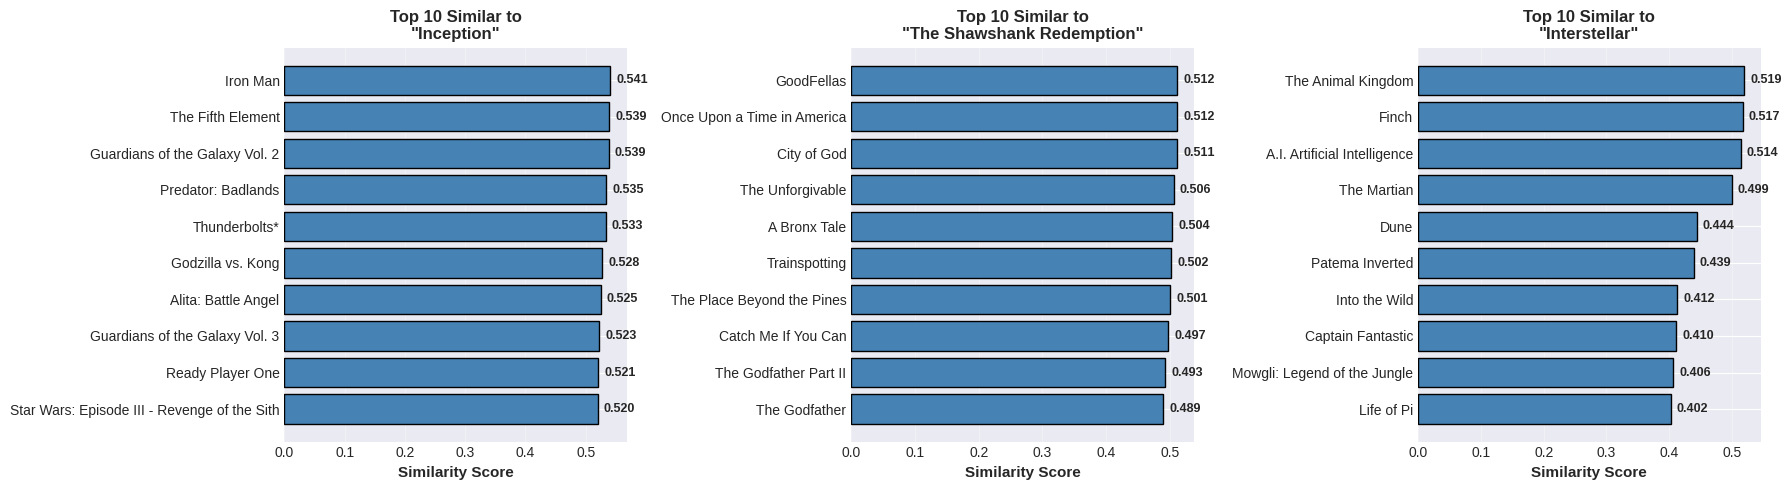

✓ Figure saved: similarity_scores.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (movie_title, results) in enumerate(all_results.items()):
    ax = axes[idx]

    ax.barh(results['title'], results['similarity_score'], color='steelblue', edgecolor='black')
    ax.set_xlabel('Similarity Score', fontsize=11, fontweight='bold')
    ax.set_title(f'Top 10 Similar to\n"{movie_title}"', fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

    for i, (_, row) in enumerate(results.iterrows()):
        ax.text(row['similarity_score'] + 0.01, i, f"{row['similarity_score']:.3f}",
                va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('similarity_scores.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 16: Visualization 2 - Hidden Gem Identification

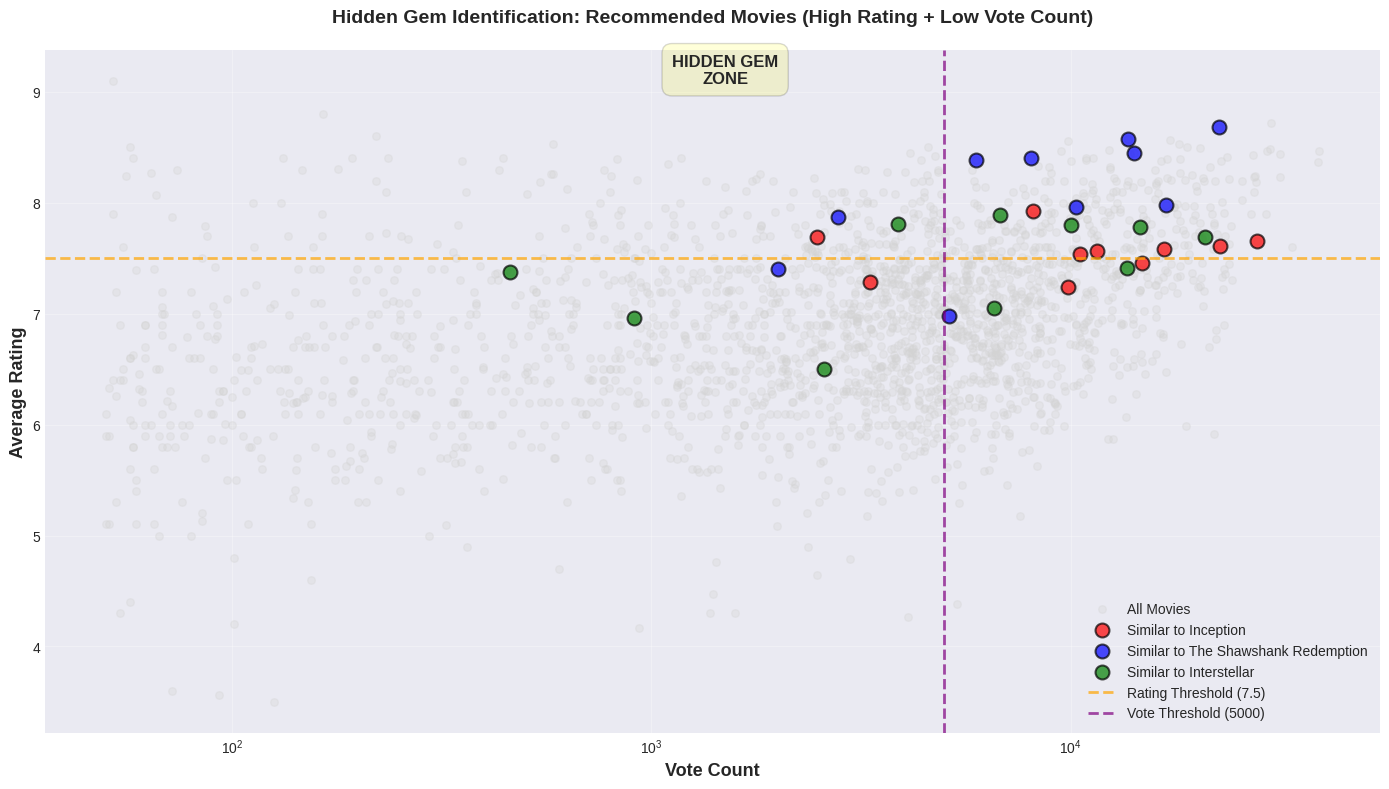

✓ Figure saved: hidden_gems.png


In [26]:
fig, ax = plt.subplots(figsize=(14, 8))

# Plot all movies in dataset
ax.scatter(df['vote_count'], df['vote_average'],
           alpha=0.3, s=30, c='lightgray', label='All Movies')

# Highlight recommended movies
colors = ['red', 'blue', 'green']
for idx, (movie_title, results) in enumerate(all_results.items()):
    ax.scatter(results['vote_count'], results['vote_average'],
               alpha=0.7, s=100, c=colors[idx],
               label=f'Similar to {movie_title}', edgecolors='black', linewidth=1.5)

# Mark hidden gem zone
ax.axhline(y=RATING_THRESHOLD, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Rating Threshold (7.5)')
ax.axvline(x=VOTE_THRESHOLD, color='purple', linestyle='--', linewidth=2, alpha=0.7, label='Vote Threshold (5000)')

# Add "Hidden Gem Zone" annotation
ax.text(1500, 9.2, 'HIDDEN GEM\nZONE', fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.15, pad=0.6),
        ha='center', va='center')

ax.set_xlabel('Vote Count', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Rating', fontsize=13, fontweight='bold')
ax.set_title('Hidden Gem Identification: Recommended Movies (High Rating + Low Vote Count)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xscale('log')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hidden_gems.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 17: Visualization 3 - Feature Contribution Heatmap

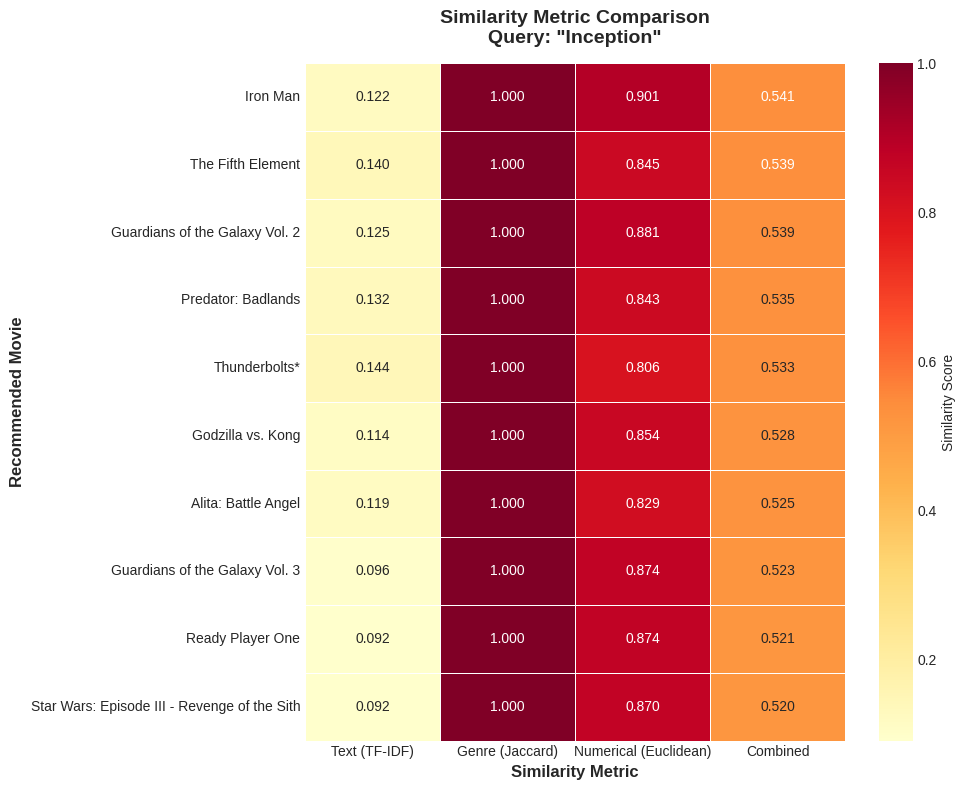

✓ Figure saved: metric_comparison.png


In [23]:
# Create comparison of similarity metrics for first query
first_query = list(query_indices.keys())[0]
query_idx = query_indices[first_query]
results = all_results[first_query]

# Get indices of top 10
top_10_indices = []
for _, row in results.iterrows():
    movie_idx = df[df['title'] == row['title']].index[0]
    top_10_indices.append(movie_idx)

# Extract similarity scores for each metric
metric_scores = {
    'Text (TF-IDF)': [cosine_sim[query_idx, i] for i in top_10_indices],
    'Genre (Jaccard)': [jaccard_sim[query_idx, i] for i in top_10_indices],
    'Numerical (Euclidean)': [euclidean_sim[query_idx, i] for i in top_10_indices],
    'Combined': [combined_similarity[query_idx, i] for i in top_10_indices]
}

# Create DataFrame
metric_df = pd.DataFrame(metric_scores, index=results['title'].tolist())

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(metric_df, annot=True, fmt='.3f', cmap='YlOrRd',
            cbar_kws={'label': 'Similarity Score'}, linewidths=0.5, ax=ax)
ax.set_title(f'Similarity Metric Comparison\nQuery: "{first_query}"',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Similarity Metric', fontsize=12, fontweight='bold')
ax.set_ylabel('Recommended Movie', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('metric_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 18: Summary Statistics

In [24]:
print("SUMMARY STATISTICS")
print("="*80)

print(f"\nDataset:")
print(f"  Total movies analyzed: {len(df)}")
print(f"  Average rating: {df['vote_average'].mean():.2f}")
print(f"  Average votes: {df['vote_count'].mean():.0f}")
print(f"  Year range: {df['year'].min():.0f} - {df['year'].max():.0f}")

print(f"\nRecommendations:")
print(f"  Queries processed: {len(query_indices)}")
print(f"  Total recommendations: {sum(len(r) for r in all_results.values())}")

# Count hidden gems across all recommendations
total_hidden_gems = 0
for results in all_results.values():
    hidden_gems = results[
        (results['vote_count'] < VOTE_THRESHOLD) &
        (results['vote_average'] >= RATING_THRESHOLD)
    ]
    total_hidden_gems += len(hidden_gems)

print(f"  Hidden gems identified: {total_hidden_gems}")
print(f"  Hidden gem rate: {total_hidden_gems / sum(len(r) for r in all_results.values()) * 100:.1f}%")

print(f"\nSimilarity Metrics:")
print(f"  Text weight (TF-IDF cosine): {weights['cosine']}")
print(f"  Genre weight (Jaccard): {weights['jaccard']}")
print(f"  Numerical weight (Euclidean): {weights['euclidean']}")

SUMMARY STATISTICS

Dataset:
  Total movies analyzed: 2266
  Average rating: 6.91
  Average votes: 5029
  Year range: 1936 - 2026

Recommendations:
  Queries processed: 3
  Total recommendations: 30
  Hidden gems identified: 3
  Hidden gem rate: 10.0%

Similarity Metrics:
  Text weight (TF-IDF cosine): 0.5
  Genre weight (Jaccard): 0.3
  Numerical weight (Euclidean): 0.2
